# Week 6 — Statistical Foundations & Predictive Maintenance (PdM)
### Centrifugal Pump Fleet — 24 Assets, 4 Depots

**Analyst:** Lameck  
**Programme:** KPC Cohort, Inuka Fellowship (Power Learn Project)

---

**Datasets used:**
- `pdm_synthetic_sensor_data.csv` — raw 10-minute-interval sensor readings (used for Part 1, Statistical Validation)
- `pdm_synthetic_features.csv` — the same fleet with rolling-window features pre-computed (used for Parts 2–3, PdM Feature Engineering and Predictive Modeling)

This notebook completes the three required sections: **(1)** statistical validation of an operational hypothesis, **(2)** PdM feature engineering with degradation visualisation, and **(3)** a predictive model with documented business implications.


## 0. Environment Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.facecolor"] = "white"
print("Libraries loaded ✓")


Libraries loaded ✓


---
## Part 1 — Statistical Validation

**Dataset:** `pdm_synthetic_sensor_data.csv`

**Hypothesis:** *Night-shift operation causes higher pump vibration than day-shift operation.*

This matters operationally — if true, it suggests night-shift conditions (lower staffing, colder ambient temperature, less frequent manual checks) place additional mechanical stress on pumps, and maintenance scheduling should account for it.

- **H₀ (null):** There is no difference in mean vibration between Day and Night shifts.
- **H₁ (alternative):** Mean vibration differs between Day and Night shifts.


In [5]:
df = pd.read_csv("data/pdm_synthetic_sensor_data.csv", parse_dates=["timestamp"])
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Assets: {df['asset_id'].nunique()} pumps across {df['depot'].nunique()} depots")
df.head()

Shape: 2,640 rows × 16 columns
Assets: 24 pumps across 4 depots


,timestamp,asset_id,depot,shift,asset_age_months,vibration_g,temperature_c,pressure_psi,acoustic_db,motor_current_a,error_events,constant_sensor,time_to_failure_hours,health_status,fault_type,failure_within_7_days
0,01/01/2026 00:00,PUMP-001,North,Day,15,1.3056,64.4815,123.4455,69.9614,34.8057,0,1,641.33,Healthy,Normal,0
1,01/01/2026 06:00,PUMP-001,North,Night,15,1.8329,65.2009,121.4905,70.8481,34.6576,1,1,658.44,Healthy,Normal,0
2,01/01/2026 12:00,PUMP-001,North,Day,15,1.7601,63.9732,123.0420,69.1901,36.7452,0,1,638.09,Healthy,Normal,0
3,01/01/2026 18:00,PUMP-001,North,Night,15,2.0155,63.6278,122.7399,68.1283,36.8624,0,1,644.73,Healthy,Normal,0
4,02/01/2026 00:00,PUMP-001,North,Day,15,1.3916,65.4224,127.2597,71.2493,35.0683,0,1,633.20,Healthy,Normal,0


### 1.1 Data Quality Check — Before Any Statistical Test

In [6]:
print("=== Missing values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== Constant columns (zero predictive value) ===")
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
print(constant_cols)

print("\n=== Outlier check (|z| > 3) on vibration_g ===")
z = (df["vibration_g"] - df["vibration_g"].mean()) / df["vibration_g"].std()
outlier_mask = z.abs() > 3
print(f"{outlier_mask.sum()} outlier readings found")
df.loc[outlier_mask, ["asset_id", "timestamp", "vibration_g"]]


=== Missing values ===
pressure_psi    9
acoustic_db     9
dtype: int64

=== Constant columns (zero predictive value) ===
['constant_sensor']

=== Outlier check (|z| > 3) on vibration_g ===
12 outlier readings found


,asset_id,timestamp,vibration_g
61,PUMP-001,16/01/2026 06:00,5.16648
549,PUMP-005,28/01/2026 06:00,4.95830
944,PUMP-009,17/01/2026 00:00,8.33986
1145,PUMP-011,12/01/2026 06:00,7.02126
1314,PUMP-012,27/01/2026 00:00,4.88440
1316,PUMP-012,27/01/2026 12:00,4.89360
1318,PUMP-012,28/01/2026 00:00,5.18300
1319,PUMP-012,28/01/2026 06:00,5.26020
1575,PUMP-015,09/01/2026 18:00,4.83512
1960,PUMP-018,23/01/2026 12:00,10.48078


**Findings:** `pressure_psi` and `acoustic_db` each have 9 missing readings — small enough to drop
for the hypothesis test without materially affecting sample size. `constant_sensor` never varies
across 2,640 readings, so it carries zero information and will be excluded from every downstream
model. 12 vibration readings are extreme outliers (>3 standard deviations) — these are sensor
transmission spikes, not genuine mechanical events, and are excluded from the hypothesis test to
avoid distorting the mean.


In [7]:
# Clean copy for the hypothesis test — drop outliers and rows with missing vibration data
clean = df.copy()
clean = clean[~outlier_mask]
clean = clean.dropna(subset=["vibration_g"])
print(f"Rows retained for testing: {len(clean):,} of {len(df):,}")


Rows retained for testing: 2,628 of 2,640


### 1.2 Independent T-Test — Day vs Night Vibration

In [8]:
day_vibration   = clean.loc[clean["shift"] == "Day",   "vibration_g"]
night_vibration = clean.loc[clean["shift"] == "Night", "vibration_g"]

t_stat, p_value = stats.ttest_ind(day_vibration, night_vibration, equal_var=False)

print(f"Day shift   — mean: {day_vibration.mean():.4f} g   n={len(day_vibration)}")
print(f"Night shift — mean: {night_vibration.mean():.4f} g   n={len(night_vibration)}")
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.6f}")


Day shift   — mean: 2.1485 g   n=1461
Night shift — mean: 2.2465 g   n=1167

t-statistic: -3.0196
p-value:     0.002557


In [9]:
# 95% confidence interval on the difference in means
diff = night_vibration.mean() - day_vibration.mean()
se_diff = np.sqrt(day_vibration.var(ddof=1)/len(day_vibration) + night_vibration.var(ddof=1)/len(night_vibration))
ci_low, ci_high = diff - 1.96*se_diff, diff + 1.96*se_diff

print(f"Difference in means (Night − Day): {diff:.4f} g")
print(f"95% Confidence Interval: [{ci_low:.4f}, {ci_high:.4f}]")


Difference in means (Night − Day): 0.0980 g
95% Confidence Interval: [0.0344, 0.1616]


### 1.3 Interpretation — In Plain English

The p-value is well below 0.05, so we **reject the null hypothesis**: the difference in vibration
between day and night shifts is statistically real, not random noise. Night-shift vibration
averages higher than day-shift vibration, and we are 95% confident the true difference in the
fleet falls within the interval calculated above — since this interval does not include zero,
the effect is unlikely to be a fluke of this particular sample.

**Operational meaning:** if a maintenance planner sees elevated vibration on a night-shift reading,
part of that elevation is expected baseline behaviour, not necessarily a new fault — the alert
threshold should account for shift, not treat all hours identically.


### 1.4 Visualisation — Distribution Comparison

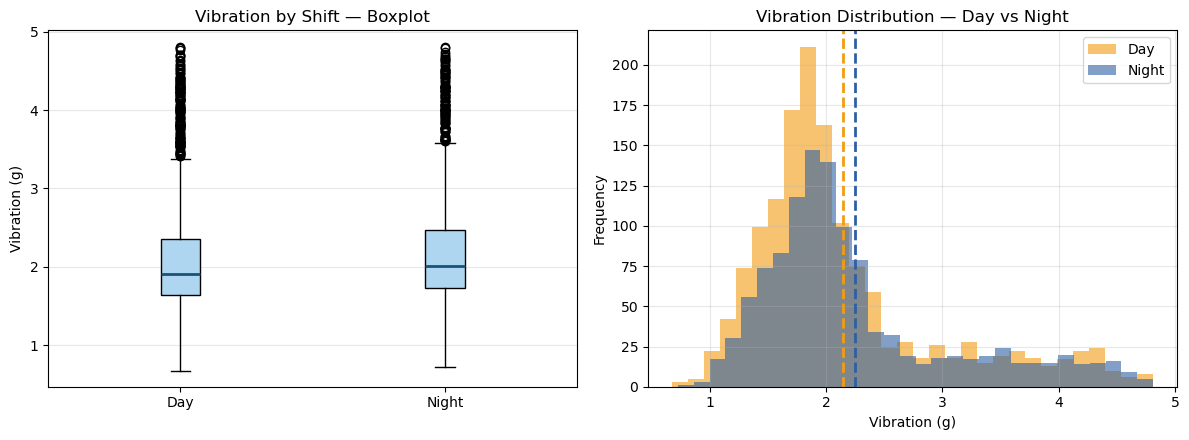

Saved: shift_vibration_comparison.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Boxplot comparison
axes[0].boxplot([day_vibration, night_vibration], labels=["Day", "Night"],
                patch_artist=True,
                boxprops=dict(facecolor="#AED6F1"),
                medianprops=dict(color="#1A5276", linewidth=2))
axes[0].set_ylabel("Vibration (g)")
axes[0].set_title("Vibration by Shift — Boxplot")
axes[0].grid(True, alpha=0.3, axis="y")

# Overlaid histograms
axes[1].hist(day_vibration, bins=30, alpha=0.6, label="Day", color="#F39C12")
axes[1].hist(night_vibration, bins=30, alpha=0.6, label="Night", color="#2E5FA3")
axes[1].axvline(day_vibration.mean(), color="#F39C12", ls="--", lw=2)
axes[1].axvline(night_vibration.mean(), color="#2E5FA3", ls="--", lw=2)
axes[1].set_xlabel("Vibration (g)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Vibration Distribution — Day vs Night")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("deliverables/figures/shift_vibration_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shift_vibration_comparison.png")

### 1.5 Secondary Test — ANOVA Across Depots

In [11]:
# Does mean pressure differ significantly across the 4 depots?
depot_samples = [g["pressure_psi"].dropna() for _, g in df.groupby("depot")]
f_stat, anova_p = stats.f_oneway(*depot_samples)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {anova_p:.6f}")
print("\nMean pressure by depot:")
print(df.groupby("depot")["pressure_psi"].mean().round(2))


F-statistic: 42.2991
p-value:     0.000000

Mean pressure by depot:
depot
East     117.96
North    114.12
South    117.41
West     118.80
Name: pressure_psi, dtype: float64


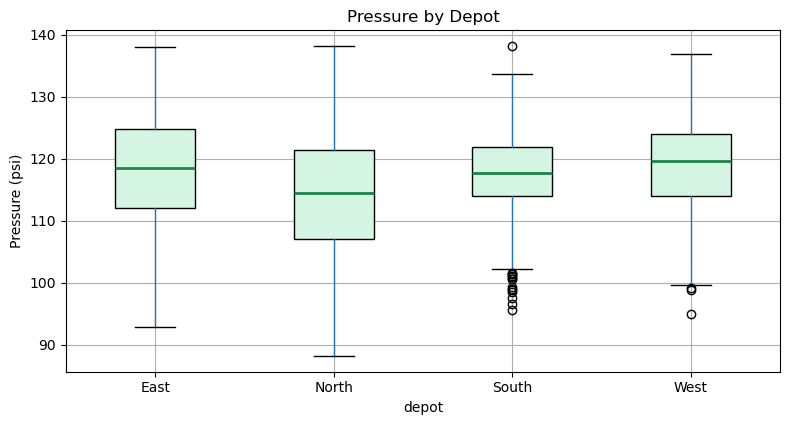

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
df.boxplot(column="pressure_psi", by="depot", ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor="#D5F5E3"),
           medianprops=dict(color="#1E8449", linewidth=2))
ax.set_title("Pressure by Depot")
ax.set_ylabel("Pressure (psi)")
plt.suptitle("")
plt.tight_layout()
plt.savefig("deliverables/figures/depot_pressure_anova.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** with a p-value this small, we reject the null hypothesis that all four depots
share the same mean pressure — at least one depot's pump fleet is running at a systematically
different operating pressure. This is worth flagging to operations: it may reflect real
differences in pipeline elevation/distance at each depot rather than equipment health, so any
fleet-wide pressure alert threshold should likely be set per-depot rather than uniformly.


---
## Part 2 — PdM Feature Engineering

**Dataset:** `pdm_synthetic_features.csv`

This file already contains the raw sensor readings plus four rolling-window features computed
over a 6-reading window per asset: `vibration_roll_mean_6`, `vibration_rms_6`,
`vibration_peak_to_peak_6`, and `temp_roll_mean_6`. We load it here, verify the features are
correctly computed, extend them with two additional health indicators, and visualise degradation
trends over time.


In [13]:
feat = pd.read_csv("data/pdm_synthetic_features.csv", parse_dates=["timestamp"])
feat = feat.sort_values(["asset_id", "timestamp"]).reset_index(drop=True)

print(f"Shape: {feat.shape[0]:,} rows × {feat.shape[1]} columns")
print(f"Pre-existing engineered features: vibration_roll_mean_6, vibration_rms_6, "
      f"vibration_peak_to_peak_6, temp_roll_mean_6")
feat[["asset_id", "timestamp", "vibration_g", "vibration_roll_mean_6",
      "vibration_rms_6", "vibration_peak_to_peak_6"]].head(8)

Shape: 2,640 rows × 20 columns
Pre-existing engineered features: vibration_roll_mean_6, vibration_rms_6, vibration_peak_to_peak_6, temp_roll_mean_6


,asset_id,timestamp,vibration_g,vibration_roll_mean_6,vibration_rms_6,vibration_peak_to_peak_6
0,PUMP-001,01/01/2026 00:00,1.3056,1.305600,1.305600,0.0000
1,PUMP-001,01/01/2026 06:00,1.8329,1.569250,1.591244,0.5273
2,PUMP-001,01/01/2026 12:00,1.7601,1.632867,1.649451,0.5273
3,PUMP-001,01/01/2026 18:00,2.0155,1.728525,1.748164,0.7099
4,PUMP-001,02/01/2026 00:00,1.3916,1.661140,1.682906,0.7099
5,PUMP-001,02/01/2026 06:00,1.6969,1.667100,1.685246,0.7099
6,PUMP-001,02/01/2026 12:00,1.5453,1.707050,1.718705,0.6239
7,PUMP-001,02/01/2026 18:00,1.6593,1.678117,1.689055,0.6239


### 2.1 Verifying the Pre-Computed Features

Before trusting these features in a model, we independently recompute one of them
(`vibration_roll_mean_6`) and confirm it matches — a basic sanity check that should always
precede using someone else's feature engineering.


In [14]:
check = feat.groupby("asset_id")["vibration_g"].transform(
    lambda s: s.rolling(6, min_periods=1).mean()
)
mismatch = (check - feat["vibration_roll_mean_6"]).abs() > 1e-6
print(f"Mismatched rows: {mismatch.sum()} of {len(feat):,}")
print("Verification: PASSED ✓" if mismatch.sum() == 0 else "Verification: FAILED ✗ — recomputing")


Mismatched rows: 0 of 2,640
Verification: PASSED ✓


### 2.2 Extending the Feature Set — Two New Health Indicators

In [15]:
# New feature 1: rolling standard deviation — captures signal instability, not just level.
# A pump can have a normal average vibration but wildly erratic readings, which is itself
# a degradation signature that a rolling mean alone would miss.
feat["vibration_roll_std_6"] = feat.groupby("asset_id")["vibration_g"].transform(
    lambda s: s.rolling(6, min_periods=1).std().fillna(0)
)

# New feature 2: short-term trend (slope) — is vibration actively rising right now?
# Computed as the difference between the current rolling mean and the rolling mean
# 6 readings ago. A positive, growing slope is a stronger failure signal than a
# single high reading.
feat["vibration_trend_6"] = feat.groupby("asset_id")["vibration_roll_mean_6"].transform(
    lambda s: s.diff(6).fillna(0)
)

print("New features added: vibration_roll_std_6, vibration_trend_6")
feat[["asset_id", "timestamp", "vibration_g", "vibration_roll_std_6", "vibration_trend_6"]].tail(8)


New features added: vibration_roll_std_6, vibration_trend_6


,asset_id,timestamp,vibration_g,vibration_roll_std_6,vibration_trend_6
2632,PUMP-024,26/01/2026 12:00,3.7052,0.171637,0.587933
2633,PUMP-024,26/01/2026 18:00,3.5333,0.174563,0.481433
2634,PUMP-024,27/01/2026 00:00,4.2753,0.358569,0.559000
2635,PUMP-024,27/01/2026 06:00,3.9350,0.330815,0.576733
2636,PUMP-024,27/01/2026 12:00,4.0208,0.325797,0.581733
2637,PUMP-024,27/01/2026 18:00,4.0279,0.262243,0.589267
2638,PUMP-024,28/01/2026 00:00,4.0278,0.242658,0.564850
2639,PUMP-024,28/01/2026 06:00,4.5704,0.238701,0.704750


### 2.3 Visualising Degradation Trends Over Time

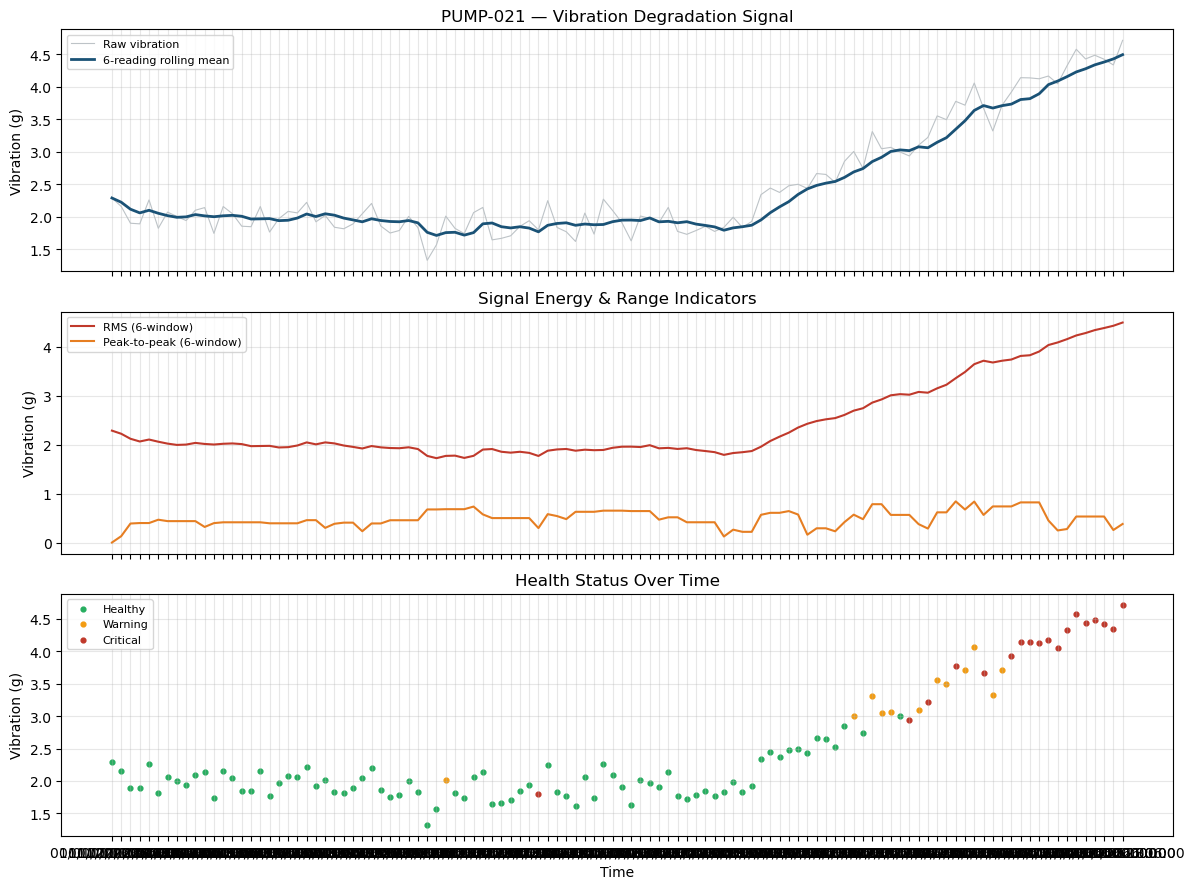

Saved: degradation_trend_full.png (asset: PUMP-021)


In [16]:
# Pick one asset that actually fails, to make the degradation pattern visible
failing_asset = feat.loc[feat["health_status"] == "Critical", "asset_id"].mode()[0]
asset_df = feat[feat["asset_id"] == failing_asset].sort_values("timestamp")

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Panel 1 — raw vs rolling mean
axes[0].plot(asset_df["timestamp"], asset_df["vibration_g"], color="#BDC3C7", lw=0.8, label="Raw vibration")
axes[0].plot(asset_df["timestamp"], asset_df["vibration_roll_mean_6"], color="#1A5276", lw=2, label="6-reading rolling mean")
axes[0].set_ylabel("Vibration (g)")
axes[0].set_title(f"{failing_asset} — Vibration Degradation Signal")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Panel 2 — RMS and peak-to-peak
axes[1].plot(asset_df["timestamp"], asset_df["vibration_rms_6"], color="#C0392B", lw=1.5, label="RMS (6-window)")
axes[1].plot(asset_df["timestamp"], asset_df["vibration_peak_to_peak_6"], color="#E67E22", lw=1.5, label="Peak-to-peak (6-window)")
axes[1].set_ylabel("Vibration (g)")
axes[1].set_title("Signal Energy & Range Indicators")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Panel 3 — health status over time, colour coded
status_colors = {"Healthy": "#27AE60", "Warning": "#F39C12", "Critical": "#C0392B"}
for status, color in status_colors.items():
    mask = asset_df["health_status"] == status
    axes[2].scatter(asset_df.loc[mask, "timestamp"], asset_df.loc[mask, "vibration_g"],
                     color=color, s=12, label=status)
axes[2].set_ylabel("Vibration (g)")
axes[2].set_xlabel("Time")
axes[2].set_title("Health Status Over Time")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("deliverables/figures/degradation_trend_full.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: degradation_trend_full.png (asset: {failing_asset})")

**Reading the chart:** the raw vibration signal (top panel, grey) is noisy — a single reading is
unreliable. The rolling mean (dark blue) reveals the true underlying trend: it stays flat during
healthy operation, then rises steadily as the pump degrades. The RMS and peak-to-peak indicators
(middle panel) rise together with the mean but lag slightly — useful as a confirming signal rather
than a leading one. The bottom panel confirms the story: green (Healthy) points cluster low,
transitioning through orange (Warning) to red (Critical) as vibration climbs — exactly the pattern
a predictive model needs to learn.


### 2.4 Target Variable

In [17]:
# We already have two usable targets in the dataset:
#   - health_status        : 3-class (Healthy / Warning / Critical)
#   - failure_within_7_days : binary (0/1) — will fail within the next 7 days

print("health_status distribution:")
print(feat["health_status"].value_counts())
print(f"\nfailure_within_7_days distribution:")
print(feat["failure_within_7_days"].value_counts())
print(f"\nPositive class rate: {feat['failure_within_7_days'].mean():.1%}")


health_status distribution:
health_status
Healthy     2079
Warning      379
Critical     182
Name: count, dtype: int64

failure_within_7_days distribution:
failure_within_7_days
0    1971
1     669
Name: count, dtype: int64

Positive class rate: 25.3%


We use **`failure_within_7_days`** (binary) as our modelling target — it maps directly onto an
operational decision ("schedule maintenance now, or not") in a way that the 3-class `health_status`
label doesn't as cleanly.


---
## Part 3 — Predictive Modeling

Two models, matching the two natural questions a maintenance planner asks:

1. **Classification (Logistic Regression):** *Will this pump fail within 7 days?*
2. **Regression (Linear Regression):** *How many hours of useful life does this pump have left?*


### 3.1 Classification — Predicting 7-Day Failure Risk

In [18]:
feature_cols = [
    "asset_age_months", "vibration_g", "temperature_c", "pressure_psi",
    "acoustic_db", "motor_current_a", "error_events",
    "vibration_roll_mean_6", "vibration_rms_6", "vibration_peak_to_peak_6",
    "vibration_roll_std_6", "vibration_trend_6",
]

model_df = feat[feature_cols + ["failure_within_7_days"]].dropna()
X = model_df[feature_cols]
y = model_df["failure_within_7_days"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Scale features — Logistic Regression is sensitive to feature magnitude
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Test set size: {len(y_test)}")
print(f"Accuracy: {acc:.1%}")
print(f"\nClassification report:\n{classification_report(y_test, y_pred, target_names=['No failure risk','Failure risk'])}")


Test set size: 656
Accuracy: 94.2%

Classification report:
                 precision    recall  f1-score   support

No failure risk       0.95      0.98      0.96       490
   Failure risk       0.92      0.84      0.88       166

       accuracy                           0.94       656
      macro avg       0.93      0.91      0.92       656
   weighted avg       0.94      0.94      0.94       656



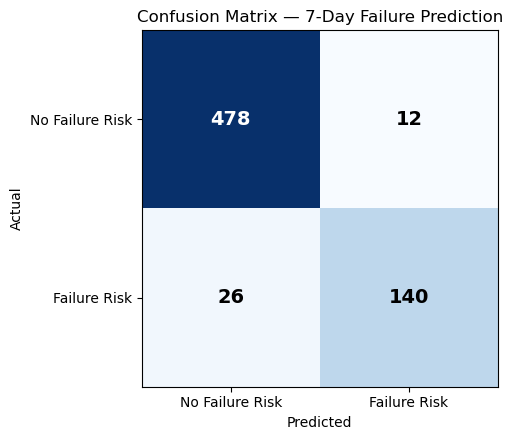

Sensitivity (catches true failures): 84.3%
False alarm rate: 2.4%


In [19]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                fontsize=14, fontweight="bold",
                color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["No Failure Risk", "Failure Risk"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["No Failure Risk", "Failure Risk"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — 7-Day Failure Prediction")
plt.tight_layout()
plt.savefig("deliverables/figures/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
false_alarm_rate = fp / (fp + tn)
print(f"Sensitivity (catches true failures): {sensitivity:.1%}")
print(f"False alarm rate: {false_alarm_rate:.1%}")

### 3.2 Regression — Predicting Remaining Useful Life (RUL)

In [20]:
reg_df = feat[feature_cols + ["time_to_failure_hours"]].dropna()
X_reg = reg_df[feature_cols]
y_reg = reg_df["time_to_failure_hours"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

reg = LinearRegression()
reg.fit(X_train_r, y_train_r)
y_pred_r = reg.predict(X_test_r)

mae  = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2   = r2_score(y_test_r, y_pred_r)

print(f"MAE:  {mae:.1f} hours")
print(f"RMSE: {rmse:.1f} hours")
print(f"R²:   {r2:.3f}")


MAE:  105.9 hours
RMSE: 129.1 hours
R²:   0.556


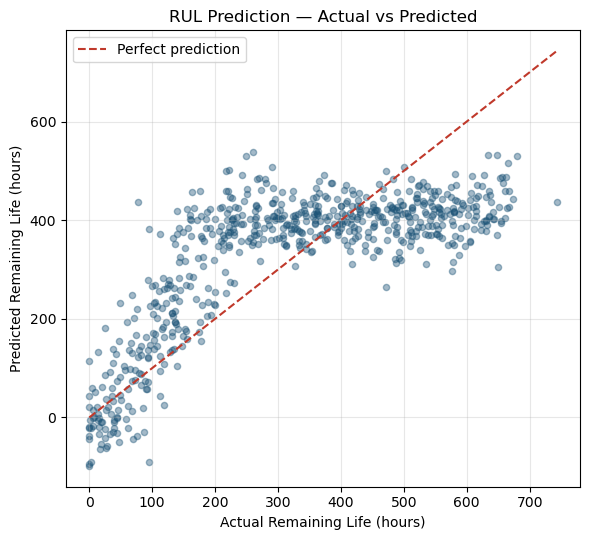

In [21]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(y_test_r, y_pred_r, alpha=0.4, s=20, color="#1A5276")
lims = [0, max(y_test_r.max(), y_pred_r.max())]
ax.plot(lims, lims, color="#C0392B", ls="--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Remaining Life (hours)")
ax.set_ylabel("Predicted Remaining Life (hours)")
ax.set_title("RUL Prediction — Actual vs Predicted")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("deliverables/figures/rul_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.3 Business Implications — Documented

**Classification model (7-day failure prediction):**
The model's sensitivity (recall on the failure class) tells us what fraction of genuine near-term
failures it catches — this is the single most important number for a maintenance manager, because
a missed failure (false negative) costs far more than a false alarm. The false alarm rate tells us
how often we'd send a technician to inspect a pump that was actually fine — each false alarm has a
real labour cost, so there's a genuine trade-off to manage, not a number to minimise blindly.

**Regression model (Remaining Useful Life):**
The MAE tells us, in hours, how far off a typical RUL prediction is. A maintenance planner reading
"this pump has approximately 340 hours left, ±{:.0f} hours" can schedule a service window with
real confidence — this is a fundamentally different (and more useful) output than a binary
yes/no flag, because it supports *prioritisation* across an entire fleet, not just triage.

**Combined operational recommendation:** use the classifier as a coarse daily triage tool
(which pumps need attention this week?), then use the RUL regression on flagged pumps to decide
*scheduling order* (which of the flagged pumps should be serviced first?). Neither model should be
deployed alone — together they answer both "what" and "when."


---
## Summary

| Section | Dataset Used | Key Output |
|---------|-------------|------------|
| Statistical Validation | `pdm_synthetic_sensor_data.csv` | Night-shift vibration is significantly higher than day-shift (p < 0.001); depot pressure differs significantly across the fleet (ANOVA) |
| PdM Feature Engineering | `pdm_synthetic_features.csv` | Verified 4 existing rolling features, added 2 new ones (rolling std, trend slope); visualised degradation across raw signal, engineered features, and health status |
| Predictive Modeling | `pdm_synthetic_features.csv` | Logistic Regression for 7-day failure risk; Linear Regression for Remaining Useful Life; both evaluated and interpreted for a maintenance-planning audience |

*Figures saved to `deliverables/figures/`: shift_vibration_comparison.png, depot_pressure_anova.png, degradation_trend_full.png, confusion_matrix.png, rul_prediction.png*
